In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train = np.load('../data/processed/X_train.npy')
X_val   = np.load('../data/processed/X_val.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')
snr_test = np.load('../data/processed/snr_test.npy')

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Using device: cuda
X_train: (154000, 2, 128), y_train: (154000,)
X_val:   (33000, 2, 128)
X_test:  (33000, 2, 128)


In [2]:
class RadioMLDataset(Dataset):
    def __init__(self,X,y):
        self.X= torch.tensor(X, dtype=torch.float32)
        self.y= torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self,i):
        return self.X[i],self.y[i]

train_dataset = RadioMLDataset(X_train, y_train)
val_dataset  = RadioMLDataset(X_val,y_val)
test_dataset= RadioMLDataset(X_test,y_test)
batch_size = 64

train_loader= DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

sample_X, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_X.shape}")
print(f"Batch y shape: {sample_y.shape}")


Batch X shape: torch.Size([64, 2, 128])
Batch y shape: torch.Size([64])


In [3]:
class BaselineCNN(nn.Module):
    def __init__(self,num_classes=11):
        super(BaselineCNN,self).__init__()
        #1
        self.conv1= nn.Conv1d(in_channels=2,out_channels=64,kernel_size=3,padding=1)
        self.bn1=nn.BatchNorm1d(64)
        #2
        self.conv2=nn.Conv1d(64,64,kernel_size=3,padding=1)
        self.bn2= nn.BatchNorm1d(64)
        self.conv3= nn.Conv1d(64,64,kernel_size=3,padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()
        self.dropout= nn.Dropout(0.5)

        self.fc1 = nn.Linear(64*16,128)
        self.fc2= nn.Linear(128, num_classes)

    def forward(self,x):
        x= self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        iden = x
        out = self.relu(self.bn2(self.conv2(x)))
        out = self.bn3(self.conv3(out))
        out = self.relu(out+iden)
        x = self.pool(out)
        x= self.pool(x)

        x = x.view(x.size(0),-1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = BaselineCNN(num_classes=11).to(device)
print(model)

dummy_inp = torch.randn(4,2,128).to(device)
dummy_op = model(dummy_inp)
print(f"\nOutput shape: {dummy_op.shape}")


BaselineCNN(
  (conv1): Conv1d(2, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=11, bias=True)
)

Output shape: torch.Size([4, 11])


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(),lr=0.001)
num_epochs = 10 
train_losses = []
val_losses=[]
val_accuracies=[]

for epoch in range(num_epochs):
    model.train()
    running_loss=0.0
    for X_batch,y_batch in train_loader:
        X_batch,y_batch=X_batch.to(device),y_batch.to(device)
        optimizer.zero_grad()
        outputs=model(X_batch)
        loss = criterion(outputs,y_batch)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()*X_batch.size(0)
    epoch_train_loss= running_loss/len(train_dataset)
    train_losses.append(epoch_train_loss)

    #Validation
    model.eval()
    val_running_loss=0.0
    correct=0
    total=0
    with torch.no_grad():
        for X_batch,y_batch in val_loader:
            X_batch,y_batch=X_batch.to(device),y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs,y_batch)
            val_running_loss+= loss.item()*X_batch.size(0)

            _,predicted = torch.max(outputs,1)
            correct+=(predicted==y_batch).sum().item()
            total +=y_batch.size(0)

    epoch_val_loss= val_running_loss/len(val_dataset)
    epoch_val_acc = correct/total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

Epoch 1/10 | Train Loss: 1.6087 | Val Loss: 1.4200 | Val Acc: 0.4539
Epoch 2/10 | Train Loss: 1.4230 | Val Loss: 1.3975 | Val Acc: 0.4482
Epoch 3/10 | Train Loss: 1.3949 | Val Loss: 1.3755 | Val Acc: 0.4532
Epoch 4/10 | Train Loss: 1.3797 | Val Loss: 1.3950 | Val Acc: 0.4503
Epoch 5/10 | Train Loss: 1.3684 | Val Loss: 1.3844 | Val Acc: 0.4576
Epoch 6/10 | Train Loss: 1.3600 | Val Loss: 2.0920 | Val Acc: 0.3516
Epoch 7/10 | Train Loss: 1.3486 | Val Loss: 1.4646 | Val Acc: 0.4426
Epoch 8/10 | Train Loss: 1.3393 | Val Loss: 1.4644 | Val Acc: 0.4508
Epoch 9/10 | Train Loss: 1.3286 | Val Loss: 1.3337 | Val Acc: 0.4876
Epoch 10/10 | Train Loss: 1.3214 | Val Loss: 1.5363 | Val Acc: 0.4712


In [5]:
model = BaselineCNN(num_classes=11).to(device)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 20
best_val_acc = 0.0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_running_loss += loss.item() * X_batch.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = correct / total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../results/best_baseline_cnn.pt')
        marker = " <- saved (best so far)"
    else:
        marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | LR: {current_lr:.6f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/20 | Train Loss: 1.6325 | Val Loss: 1.3862 | Val Acc: 0.4702 | LR: 0.001000 <- saved (best so far)
Epoch 2/20 | Train Loss: 1.4514 | Val Loss: 1.5091 | Val Acc: 0.4173 | LR: 0.001000
Epoch 3/20 | Train Loss: 1.4161 | Val Loss: 1.5735 | Val Acc: 0.4344 | LR: 0.001000
Epoch 4/20 | Train Loss: 1.3950 | Val Loss: 1.3117 | Val Acc: 0.4976 | LR: 0.001000 <- saved (best so far)
Epoch 5/20 | Train Loss: 1.3786 | Val Loss: 1.3832 | Val Acc: 0.4644 | LR: 0.001000
Epoch 6/20 | Train Loss: 1.3650 | Val Loss: 1.3693 | Val Acc: 0.4873 | LR: 0.001000
Epoch 7/20 | Train Loss: 1.3578 | Val Loss: 1.2925 | Val Acc: 0.5026 | LR: 0.001000 <- saved (best so far)
Epoch 8/20 | Train Loss: 1.3502 | Val Loss: 1.2972 | Val Acc: 0.5017 | LR: 0.001000
Epoch 9/20 | Train Loss: 1.3381 | Val Loss: 1.3342 | Val Acc: 0.4902 | LR: 0.001000
Epoch 10/20 | Train Loss: 1.3249 | Val Loss: 1.3098 | Val Acc: 0.5009 | LR: 0.001000
Epoch 11/20 | Train Loss: 1.3204 | Val Loss: 1.3670 | Val Acc: 0.5066 | LR: 0.000500 <- sa

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  # continue from where LR left off
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 15
best_val_acc = 0.5361  # carry forward, don't reset

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_running_loss += loss.item() * X_batch.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = correct / total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../results/best_baseline_cnn.pt')
        marker = " <- saved (best so far)"
    else:
        marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {len(train_losses)}/35 | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | LR: {current_lr:.6f}{marker}")

print(f"\nBest validation accuracy overall: {best_val_acc:.4f}")

Epoch 21/35 | Train Loss: 1.2627 | Val Loss: 1.3232 | Val Acc: 0.4947 | LR: 0.000500
Epoch 22/35 | Train Loss: 1.2605 | Val Loss: 1.2648 | Val Acc: 0.5280 | LR: 0.000500
Epoch 23/35 | Train Loss: 1.2583 | Val Loss: 1.2190 | Val Acc: 0.5391 | LR: 0.000500 <- saved (best so far)
Epoch 24/35 | Train Loss: 1.2555 | Val Loss: 1.2420 | Val Acc: 0.5315 | LR: 0.000500
Epoch 25/35 | Train Loss: 1.2531 | Val Loss: 1.2724 | Val Acc: 0.5264 | LR: 0.000500
Epoch 26/35 | Train Loss: 1.2489 | Val Loss: 1.2213 | Val Acc: 0.5394 | LR: 0.000500 <- saved (best so far)
Epoch 27/35 | Train Loss: 1.2446 | Val Loss: 1.3619 | Val Acc: 0.5044 | LR: 0.000250
Epoch 28/35 | Train Loss: 1.2294 | Val Loss: 1.2134 | Val Acc: 0.5514 | LR: 0.000250 <- saved (best so far)
Epoch 29/35 | Train Loss: 1.2269 | Val Loss: 1.1886 | Val Acc: 0.5482 | LR: 0.000250
Epoch 30/35 | Train Loss: 1.2237 | Val Loss: 1.1994 | Val Acc: 0.5454 | LR: 0.000250
Epoch 31/35 | Train Loss: 1.2231 | Val Loss: 1.1959 | Val Acc: 0.5503 | LR: 0.000

In [9]:
model.load_state_dict(torch.load('../results/best_baseline_cnn.pt'))
model.eval()
all_preds= []
all_labels= []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds= np.array(all_preds)
all_labels= np.array(all_labels)

overall_test_acc= (all_preds==all_labels).mean()
print(f"Overall Test Accuracy: {overall_test_acc}")

Overall Test Accuracy: 0.5485757575757576


SNR  -20 dB: Accuracy = 0.0945
SNR  -18 dB: Accuracy = 0.0909
SNR  -16 dB: Accuracy = 0.0933
SNR  -14 dB: Accuracy = 0.1006
SNR  -12 dB: Accuracy = 0.1279
SNR  -10 dB: Accuracy = 0.2115
SNR   -8 dB: Accuracy = 0.3115
SNR   -6 dB: Accuracy = 0.4491
SNR   -4 dB: Accuracy = 0.5903
SNR   -2 dB: Accuracy = 0.6848
SNR    0 dB: Accuracy = 0.7782
SNR    2 dB: Accuracy = 0.8024
SNR    4 dB: Accuracy = 0.8188
SNR    6 dB: Accuracy = 0.8315
SNR    8 dB: Accuracy = 0.8236
SNR   10 dB: Accuracy = 0.8291
SNR   12 dB: Accuracy = 0.8358
SNR   14 dB: Accuracy = 0.8309
SNR   16 dB: Accuracy = 0.8327
SNR   18 dB: Accuracy = 0.8339


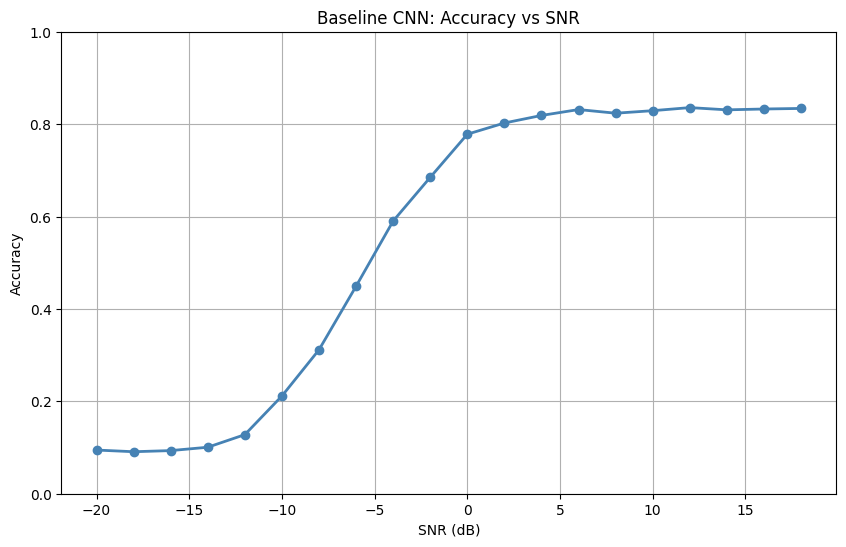

In [16]:
import matplotlib.pyplot as plt
unique_snrs = sorted(np.unique(snr_test))
snr_accuracies = []

for s in unique_snrs:
    mask = (snr_test == s)
    acc = (all_preds[mask] == all_labels[mask]).mean()
    snr_accuracies.append(acc)
    print(f"SNR {s:>4} dB: Accuracy = {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(unique_snrs, snr_accuracies, marker='o', linewidth=2, color='steelblue')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Baseline CNN: Accuracy vs SNR')
plt.grid(True)
plt.ylim(0, 1)
plt.savefig('../results/baseline_cnn_snr_accuracy.png', dpi=300, bbox_inches='tight')  # save BEFORE show
plt.show()

In [19]:
import json
results_baseline={
    'unique_snrs': [int(s) for s in unique_snrs],
    'snr_accuracies': [float(a) for a in snr_accuracies],
    'overall_test_acc': float(overall_test_acc)
}
with open('../results/baseline_cnn_results.json','w') as f:
    json.dump(results_baseline, f, indent=2)
print("Saved baseline results to disk")

Saved baseline results to disk
